In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score,fbeta_score, roc_curve, roc_auc_score, precision_recall_curve,auc, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, SGDClassifier, Ridge, Lasso

In [34]:
df = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\train.csv') 
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [35]:
df['Age'] =df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

In [36]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'], axis=1)

In [37]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000
887,1,1,female,19.0,0,0,30.0000
888,0,3,female,21.5,1,2,23.4500
889,1,1,male,26.0,0,0,30.0000


In [38]:
df['Sex'] = (df['Sex'] == 'male').astype('int')
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,1,22.0,1,0,7.2500
1,1,1,0,38.0,1,0,71.2833
2,1,3,0,26.0,0,0,7.9250
3,1,1,0,35.0,1,0,53.1000
4,0,3,1,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000
887,1,1,0,19.0,0,0,30.0000
888,0,3,0,21.5,1,2,23.4500
889,1,1,1,26.0,0,0,30.0000


In [39]:
X=np.array(df[['Pclass','Sex','Age']]) ## Создаем маасив X - матрицу с признаками: пол, возраст, класс
X

array([[ 3. ,  1. , 22. ],
       [ 1. ,  0. , 38. ],
       [ 3. ,  0. , 26. ],
       ...,
       [ 3. ,  0. , 21.5],
       [ 1. ,  1. , 26. ],
       [ 3. ,  1. , 32. ]], shape=(891, 3))

In [40]:
y=np.array(df[['Survived']]) ## y - известный параметр выживания

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)

In [42]:
model=LogisticRegression() ## Обучаем логистическую  модель 
model.fit(X_train,y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
model.coef_,model.intercept_ ## находим веса модели (wo-w3)

(array([[-1.09307963, -2.44597544, -0.02820672]]), array([4.29402277]))

In [43]:
y_pred=model.predict(X_test) ## предсказание по тестовой выборке
y_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1])

In [44]:
df=pd.DataFrame(X_test) ## Таблица результатов через фунцию LogisticRegression()
df['y_test']=y_test
df['y_pred']=y_pred
df.head()

,0,1,2,y_test,y_pred
0,3.0,1.0,25.0,1,0
1,2.0,1.0,31.0,0,0
2,3.0,1.0,20.0,0,0
3,2.0,0.0,6.0,1,1
4,3.0,0.0,14.0,1,1


In [45]:
accuracy_score(y_test, y_pred,normalize=True)  ##Точность логистической регрессии

0.8100558659217877

In [46]:
model.score(X_test,y_test) ##Точность логистической регрессии

0.8100558659217877

In [47]:
conf_matrix=confusion_matrix(y_test,y_pred) ##Выводим матрицу ошибок

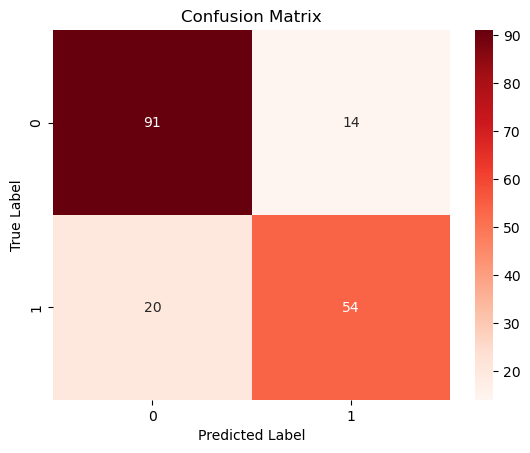

In [48]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [49]:
precision = precision_score(y_test, y_pred) ## находим precision ( долю правильно предсказанных положительных классов среди всех образцов, которые модель спрогнозировала как положительный класс)
precision

0.7941176470588235

In [50]:
recall = recall_score(y_test, y_pred) ## находим recall (отражает долю правильно предсказанных положительных классов среди всех реальных положительных образцов)
recall

0.7297297297297297

In [51]:
f1 = f1_score(y_test, y_pred)## находим f1 (гармоническое среднее между precision и recall )
f1

0.7605633802816901

In [52]:
## Уровень 2

In [143]:
df = pd.read_csv("C:\\Users\\User\\Documents\\ДЗ\\boston_house_prices.csv", header=1)
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


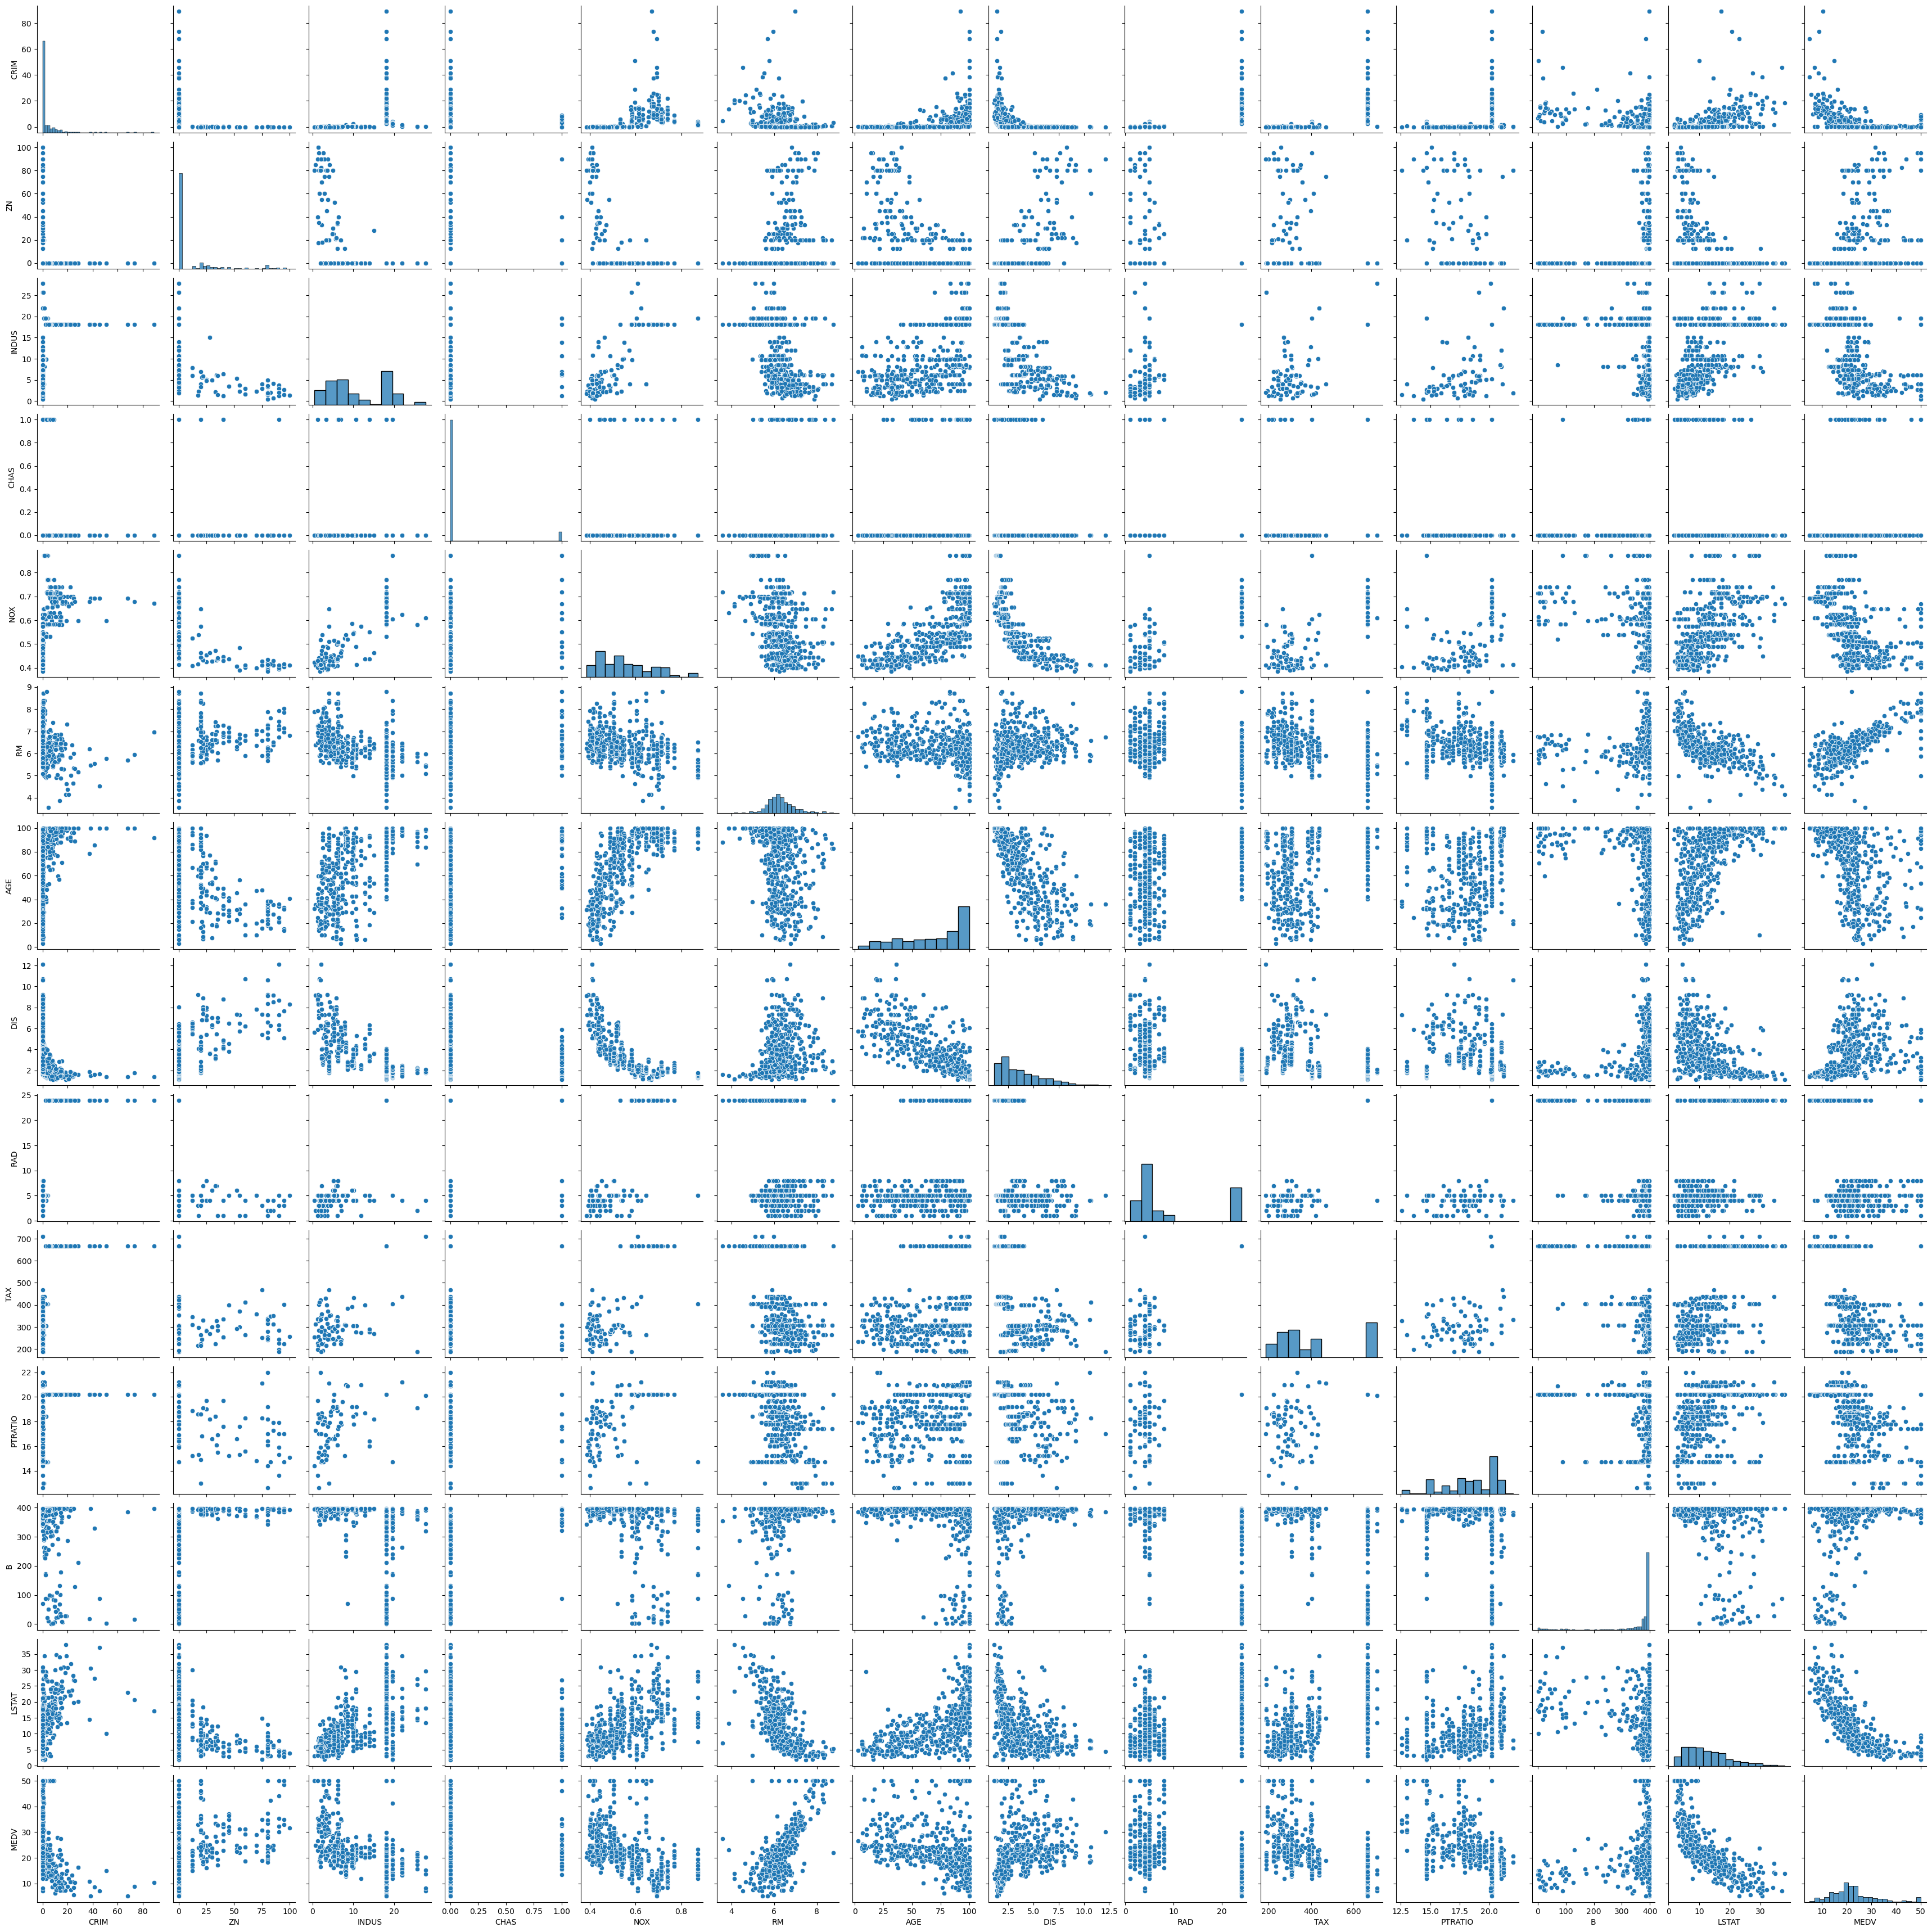

In [144]:
sns.pairplot(df)

In [55]:
x_df = pd.DataFrame(data['data'], columns=data['feature_names'])
y_df = pd.DataFrame(data['target'], columns=['y'])

In [145]:
y=df[['MEDV']]

In [146]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(df[['LSTAT']], y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
from sklearn.metrics import mean_squared_error
y_pred = model.predict(df[['LSTAT']])
mean_squared_error(y_pred, df[['MEDV']])

38.48296722989414

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


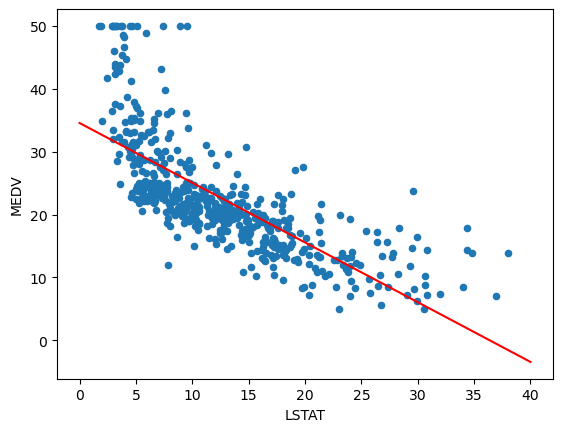

In [148]:
x = np.linspace(0, 40, 100).reshape(-1, 1) # Делаем reshape, чтобы x стал матрицей с одним столбцом
y = model.predict(x)
df.loc[df[['LSTAT']].index].plot(kind='scatter', x='LSTAT', y='MEDV')
plt.plot(x, y, color='r')

In [149]:
df['LSTAT^2'] = df['LSTAT'] ** 2
square_model = LinearRegression()
# Обучаемся уже на двух колонках
square_model.fit(df[['LSTAT', 'LSTAT^2']], df[['MEDV']])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


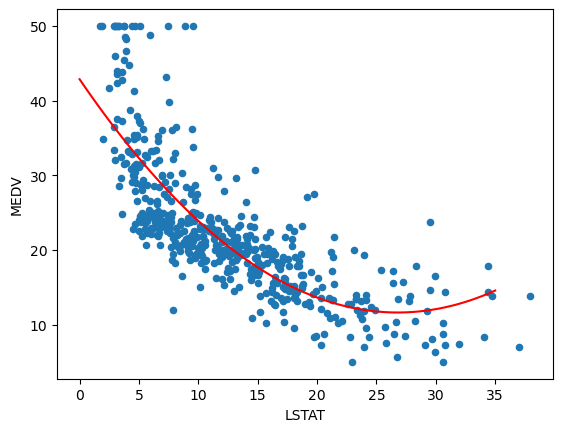

In [150]:
# Выведем общую ошибку на тестовой выборке
y_pred = square_model.predict(df[['LSTAT', 'LSTAT^2']])
x = np.linspace(0, 35, 100).reshape(-1, 1) # Делаем reshape, чтобы x стал матрицей с одним столбцом
x_square = x ** 2
x = np.hstack([x, x_square])
y = square_model.predict(x)
df.loc[df[['LSTAT']].index].plot(kind='scatter', x='LSTAT', y='MEDV')
plt.plot(x[:, 0], y, color='r')

In [151]:
y_pred = model.predict(df[['LSTAT']])
mean_squared_error(y_pred, df[['MEDV']])

38.48296722989414

In [152]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [153]:
x_df = pd.DataFrame(data['data'], columns=data['feature_names'])
y_df = pd.DataFrame(data['target'], columns=['y'])

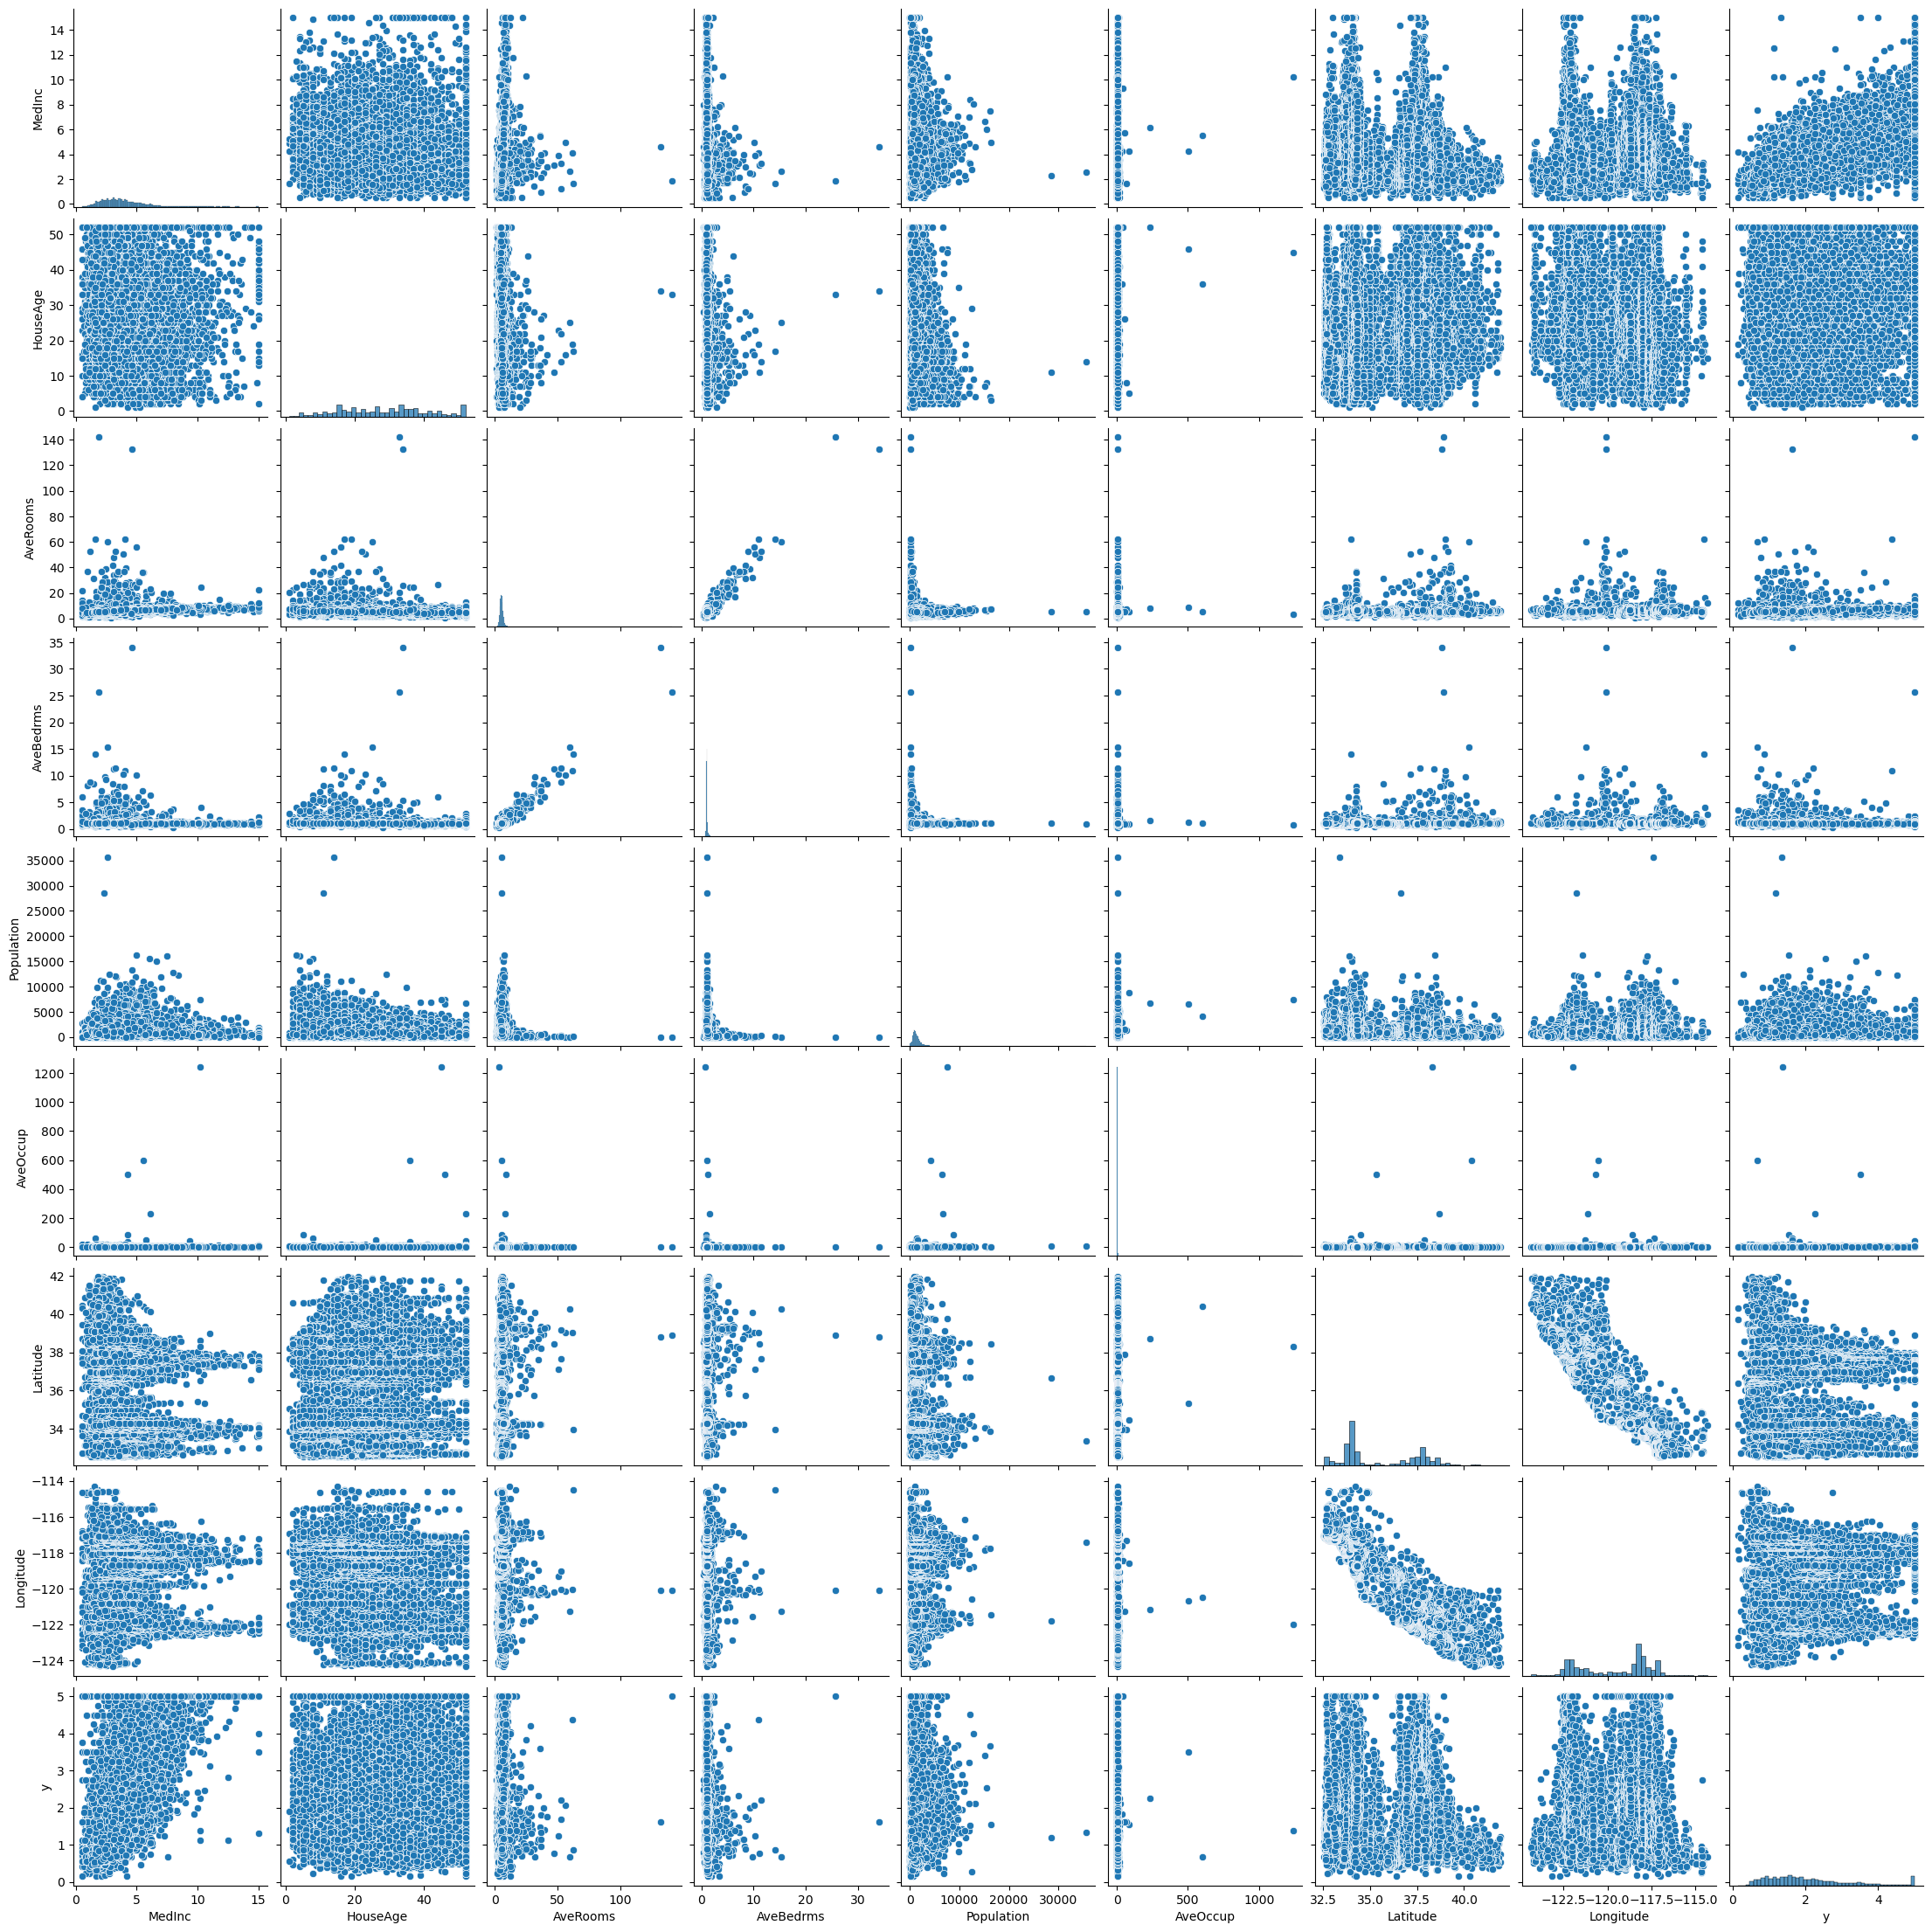

In [154]:
full_df = pd.concat([x_df, y_df], axis=1)
sns.pairplot(full_df)

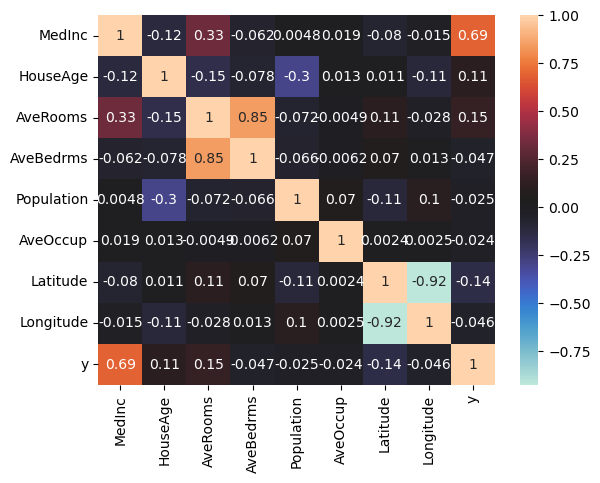

In [155]:
sns.heatmap(full_df.corr(), annot=True, cmap='icefire');

In [156]:
## Уровень 3

In [157]:
data = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\weight-height.csv') 
data

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [106]:
data.isna().sum()

Gender    0
Height    0
Weight    0
dtype: int64

In [107]:
df=data[data['Gender']=='Male']
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
4995,Male,68.860062,177.131052
4996,Male,68.973423,159.285228
4997,Male,67.013795,199.195400
4998,Male,71.557718,185.905909


<Axes: xlabel='Height', ylabel='Weight'>

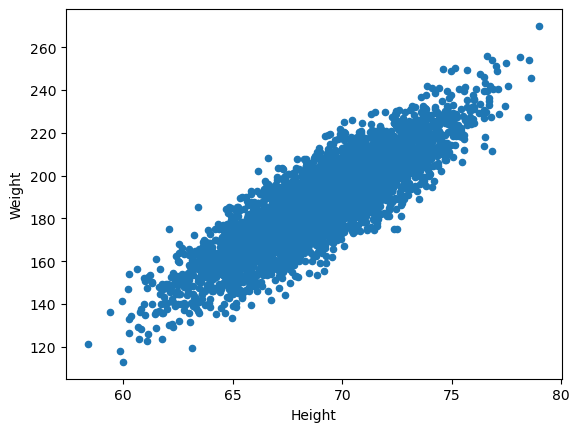

In [108]:
df.plot(kind='scatter', x='Height', y='Weight')

In [109]:
n=len(X)
n

5000

In [110]:
df1=df.drop('Gender',axis=1) 
df1

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
4995,68.860062,177.131052
4996,68.973423,159.285228
4997,67.013795,199.195400
4998,71.557718,185.905909


In [111]:
df1=np.array(df1)
df1

array([[ 73.84701702, 241.89356318],
       [ 68.78190405, 162.31047252],
       [ 74.11010539, 212.74085556],
       ...,
       [ 67.01379497, 199.19540008],
       [ 71.55771849, 185.90590949],
       [ 70.35187988, 198.90301194]], shape=(5000, 2))

In [112]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df1)

In [113]:
scaled_data

array([[ 1.68373851,  2.77427845],
       [-0.08537736, -1.24930117],
       [ 1.77562863,  1.30036936],
       ...,
       [-0.70293315,  0.61553521],
       [ 0.88414443, -0.05635782],
       [ 0.4629755 ,  0.60075258]], shape=(5000, 2))

In [114]:
df=pd.DataFrame(scaled_data)
df

,0,1
0,1.683739,2.774278
1,-0.085377,-1.249301
2,1.775629,1.300369
3,0.944660,1.669526
4,0.298787,0.977249
...,...,...
4995,-0.058079,-0.499999
4996,-0.018485,-1.402252
4997,-0.702933,0.615535
4998,0.884144,-0.056358


In [125]:
X=np.array(df[0])
y=np.array(df[1])


In [126]:
##Функция, определяющая квадратичную ошибку
def mse(X,w,b,y):
    y_n=np.array(w*X+b)
    return np.sum((y-y_n)**2/len(y_n))


In [127]:
##Функция, градиента
def grad(X,w,b,y):
    y_n=np.array(w*X+b)
    return np.array([2/n*np.sum((y-y_n))*(-1),## Берем производную  dMSE/db
                     2/n*np.sum((y-y_n) @ (-X))]) ## Берем производную  dMSE/dw
     
    

In [136]:
eps=0.001 ## Установка минимального значения на которое должны изменяться веса
## первоначальные точки
w=100
b=100
learn_rate = 0.1 ## размер шага
w_new=w
b_new=b
iter = 200 ## количество итераций
for i in range (iter):## Запускаем градиентный спуск
    w_old=w_new
    b_old=b_new   
    w_new = w_old - learn_rate*grad(X,w_old,b_old,y)[1]
    b_new = b_old - learn_rate*grad(X,w_old,b_old,y)[0]

    print(f"Итерация:{i}")
    print(f"Текущая точка:{w_old,b_old} Следующая точка{w_new,b_new} ")
    print(f"MSE:{mse(X,w_new,b_new,y)}")
    print()
    ## Остановка, когда достигнута нобх. степень точности
    if (abs(w_old-w_new)<=eps) and (abs(b_old-b_new)<=eps):
        break

Итерация:0
Текущая точка:(100, 100) Следующая точка(np.float64(80.17259576972323), np.float64(79.99999999999997)) 
MSE:12690.270603679583

Итерация:1
Текущая точка:(np.float64(80.17259576972323), np.float64(79.99999999999997)) Следующая точка(np.float64(64.31067238550182), np.float64(63.99999999999995)) 
MSE:8121.865082657389

Итерация:2
Текущая точка:(np.float64(64.31067238550182), np.float64(63.99999999999995)) Следующая точка(np.float64(51.6211336781247), np.float64(51.19999999999994)) 
MSE:5198.085549203188

Итерация:3
Текущая точка:(np.float64(51.6211336781247), np.float64(51.19999999999994)) Следующая точка(np.float64(41.469502712223004), np.float64(40.95999999999994)) 
MSE:3326.8666477925

Итерация:4
Текущая точка:(np.float64(41.469502712223004), np.float64(40.95999999999994)) Следующая точка(np.float64(33.34819793950165), np.float64(32.76799999999994)) 
MSE:2129.286550889661

Итерация:5
Текущая точка:(np.float64(33.34819793950165), np.float64(32.76799999999994)) Следующая точка

In [137]:
print('w=',w_new,'b=',b_new)

w= 0.8664332696295024 b= 0.0034844914372696425


In [138]:
df['y_pred']=df[0]*w_new+b_new

In [139]:
df

,0,1,y_pred
0,1.683739,2.774278,1.462332
1,-0.085377,-1.249301,-0.070489
2,1.775629,1.300369,1.541948
3,0.944660,1.669526,0.821969
4,0.298787,0.977249,0.262364
...,...,...,...
4995,-0.058079,-0.499999,-0.046837
4996,-0.018485,-1.402252,-0.012531
4997,-0.702933,0.615535,-0.605560
4998,0.884144,-0.056358,0.769537


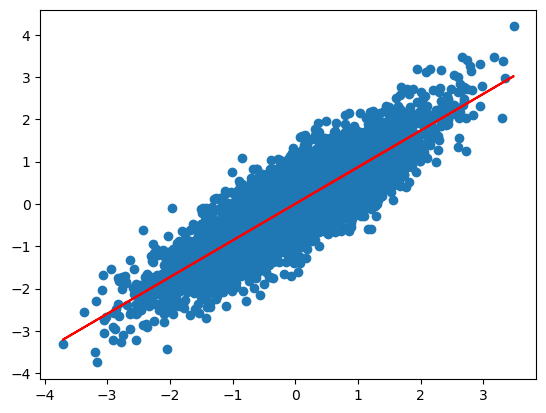

In [142]:
plt.scatter(df[0],df[1])
plt.plot(df[0],df['y_pred'],color="red")